# 03 — Feature Engineering
## The Five Cs, Turned into Columns

**Credit Scoring Capstone — Module 1**

The raw application answers a questionnaire; the bureau file records behavior. This notebook converts both into the features a credit model actually learns from, each tied to a lending rationale:

| C | Question | Features built here |
|---|---|---|
| **Character** | Did they repay others? | 17 bureau aggregates: overdue counts and amounts, utilization, credit age, thin-file flag |
| **Capacity** | Can they afford the payment? | `DTI`, `CREDIT_TO_INCOME`, `INCOME_PER_PERSON`, `EMPLOYED_SHARE_OF_LIFE` |
| **Capital** | What do they own? | car/realty flags (native), `OWN_CAR_AGE` |
| **Collateral** | Is the loan covered? | `CREDIT_TO_GOODS`, `ANNUITY_TO_CREDIT` |
| **Conditions** | External context? | `EXT_SOURCE_MEAN/MIN/COUNT`, region ratings, K-Means **peer groups** |

Everything stateless (row-wise ratios, per-applicant aggregation) is applied to all three splits identically. Everything *fitted* — the K-Means peer groups and their scaler — is fitted on **train only**.

In [1]:
import sys, warnings, json
sys.path.append("..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import QuantileTransformer

from src import config, data, features, plotting
from src.plotting import (SERIES, BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN,
                          VIOLET, RED, MUTED, INK_2, GRID, GOOD, CRITICAL,
                          direct_label, fmt_pct, subtitle, save_figure)

plotting.apply_style()
config.set_seed()

train = pd.read_parquet(config.PROCESSED_DIR / "train_clean.parquet")
val = pd.read_parquet(config.PROCESSED_DIR / "val_clean.parquet")
test = pd.read_parquet(config.PROCESSED_DIR / "test_clean.parquet")
print(f"train {train.shape}   val {val.shape}   test {test.shape}")

train (215257, 127)   val (46127, 127)   test (46127, 127)


---
## 1. Capacity & Collateral Ratios (stateless, row-wise)

In [2]:
train, val, test = map(features.add_ratio_features, (train, val, test))
new_ratios = ["DTI", "CREDIT_TO_INCOME", "CREDIT_TO_GOODS", "ANNUITY_TO_CREDIT",
              "INCOME_PER_PERSON", "EMPLOYED_SHARE_OF_LIFE",
              "EXT_SOURCE_MEAN", "EXT_SOURCE_MIN", "EXT_SOURCE_COUNT", "DOCUMENT_COUNT"]
train[new_ratios].describe().T.round(3)[["mean", "std", "min", "50%", "max"]]

,mean,std,min,50%,max
DTI,0.181,0.095,0.000,0.163,1.452000e+00
CREDIT_TO_INCOME,3.959,2.685,0.005,3.269,4.922700e+01
CREDIT_TO_GOODS,1.123,0.123,0.150,1.119,5.000000e+00
ANNUITY_TO_CREDIT,0.054,0.022,0.022,0.050,1.240000e-01
INCOME_PER_PERSON,93307.914,111314.344,3375.000,75000.000,3.900000e+07
EMPLOYED_SHARE_OF_LIFE,0.157,0.134,-0.000,0.119,7.180000e-01
EXT_SOURCE_MEAN,0.509,0.150,0.000,0.524,8.790000e-01
EXT_SOURCE_MIN,0.399,0.187,0.000,0.403,8.790000e-01
EXT_SOURCE_COUNT,2.235,0.650,0.000,2.000,3.000000e+00
DOCUMENT_COUNT,0.930,0.345,0.000,1.000,4.000000e+00


---
## 2. Character: 1.7M Bureau Rows → 17 Features per Applicant

Aggregation is per-`SK_ID_CURR` and uses only that applicant's own bureau records, so it is split-safe by construction — an applicant's features are identical regardless of which split they landed in.

In [3]:
bureau = data.load_bureau()
bagg = features.aggregate_bureau(bureau)
train, val, test = (features.merge_bureau(d, bagg) for d in (train, val, test))
buro_cols = [c for c in train.columns if c.startswith("BURO_")] + ["HAS_BUREAU_FILE"]
print(f"bureau features: {len(buro_cols)}")
train[["BURO_COUNT", "BURO_ACTIVE_COUNT", "BURO_OVERDUE_SHARE",
       "BURO_UTILIZATION_MEAN", "BURO_DEBT_TO_CREDIT", "BURO_OLDEST_YEARS"]].describe().T.round(3)[["mean", "50%", "max"]]

bureau features: 17


,mean,50%,max
BURO_COUNT,4.750,4.000,94.000
BURO_ACTIVE_COUNT,2.053,2.000,32.000
BURO_OVERDUE_SHARE,0.003,0.000,1.000
BURO_UTILIZATION_MEAN,0.245,0.188,2.000
BURO_DEBT_TO_CREDIT,0.282,0.208,6.994
BURO_OLDEST_YEARS,4.822,5.002,8.000


---
## 3. Do the Engineered Features Carry Signal? Single-Feature AUROC

Each feature used alone as a "model": AUROC 0.50 = no signal. This is the honest ranking of what we just built (computed on train; median-filled for the scoring only).

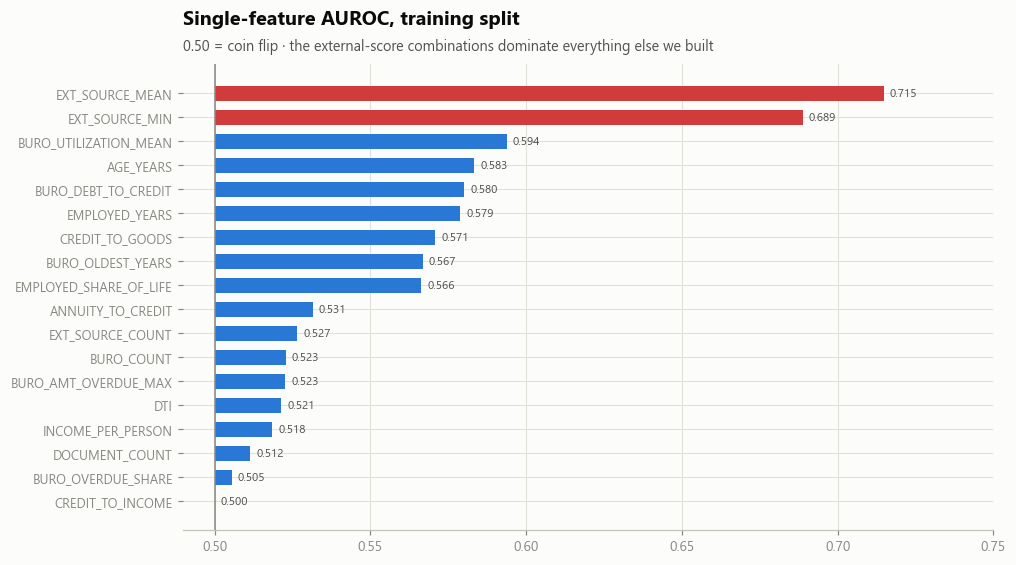

In [4]:
candidates = new_ratios + ["BURO_OVERDUE_SHARE", "BURO_UTILIZATION_MEAN",
                           "BURO_DEBT_TO_CREDIT", "BURO_COUNT", "BURO_OLDEST_YEARS",
                           "BURO_AMT_OVERDUE_MAX", "AGE_YEARS", "EMPLOYED_YEARS"]
y = train["TARGET"]
aucs = {}
for c in candidates:
    x = train[c].fillna(train[c].median())
    a = roc_auc_score(y, x)
    aucs[c] = max(a, 1 - a)   # orientation-free
aucs = pd.Series(aucs).sort_values()

fig, ax = plt.subplots(figsize=(9.5, 5.5))
colors = [BLUE if v < 0.6 else ORANGE if v < 0.68 else CRITICAL for v in aucs]
ax.barh(range(len(aucs)), aucs.values - 0.5, left=0.5, color=colors, height=0.65)
ax.set_yticks(range(len(aucs))); ax.set_yticklabels(aucs.index, fontsize=8.5)
ax.axvline(0.5, color=MUTED, lw=1)
ax.set_xlim(0.49, 0.75)
ax.set_title("Single-feature AUROC, training split")
subtitle(ax, "0.50 = coin flip \u00b7 the external-score combinations dominate everything else we built")
for i, v in enumerate(aucs.values):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=7.5, color=INK_2)
save_figure(fig, "fe_single_feature_auc")
plt.show()

---
## 4. Peer Groups via K-Means (Unsupervised Structure as a Feature)

Applicants cluster into financial "peer groups" — young renters with thin files, established homeowners, high-leverage borrowers. A cluster id gives every downstream model a compact nonlinear summary of *who this applicant resembles*, and gives the business a segmentation it can talk about.

Fitted strictly on train: median-impute → **quantile-transform to a normal shape** → K-Means. The quantile step matters: incomes here span 26k to 117M, and a plain standard-scaler lets a handful of extreme rows hijack whole clusters (we saw exactly that on a first attempt — one "cluster" of a few outlier applicants at 100% default). Rank-normalizing makes every feature contribute comparably. k chosen by silhouette on a 20k sample.

In [5]:
CLUSTER_FEATURES = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AGE_YEARS",
                    "EMPLOYED_YEARS", "EXT_SOURCE_MEAN", "DTI", "CREDIT_TO_INCOME",
                    "BURO_COUNT", "BURO_DEBT_TO_CREDIT"]

prep = Pipeline([("impute", SimpleImputer(strategy="median")),
                 ("scale", QuantileTransformer(output_distribution="normal",
                                               n_quantiles=1000, subsample=100_000,
                                               random_state=config.SEED))])
Xc_train = prep.fit_transform(train[CLUSTER_FEATURES])

sample_idx = np.random.default_rng(config.SEED).choice(len(Xc_train), 20000, replace=False)
sil = {}
for k in [3, 4, 5, 6, 8, 10]:
    km = KMeans(n_clusters=k, n_init=5, random_state=config.SEED).fit(Xc_train[sample_idx])
    sil[k] = silhouette_score(Xc_train[sample_idx], km.labels_, sample_size=8000,
                              random_state=config.SEED)
sil = pd.Series(sil)
best_k = int(sil.idxmax())
print("silhouette by k:", sil.round(3).to_dict(), "-> chosen k =", best_k)

kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=config.SEED).fit(Xc_train)
for d, X in [(train, Xc_train), (val, None), (test, None)]:
    Xd = X if X is not None else prep.transform(d[CLUSTER_FEATURES])
    d["PEER_GROUP"] = kmeans.predict(Xd).astype("int8")

joblib.dump({"prep": prep, "kmeans": kmeans, "features": CLUSTER_FEATURES},
            config.MODELS_DIR / "peer_group_clusterer.pkl")

silhouette by k: {3: 0.212, 4: 0.175, 5: 0.164, 6: 0.159, 8: 0.131, 10: 0.126} -> chosen k = 3


['C:\\Users\\mailt\\OneDrive\\Desktop\\Jarviss\\Project-Deep Learning\\Module_1_intro_to_ML\\capstone\\models\\peer_group_clusterer.pkl']

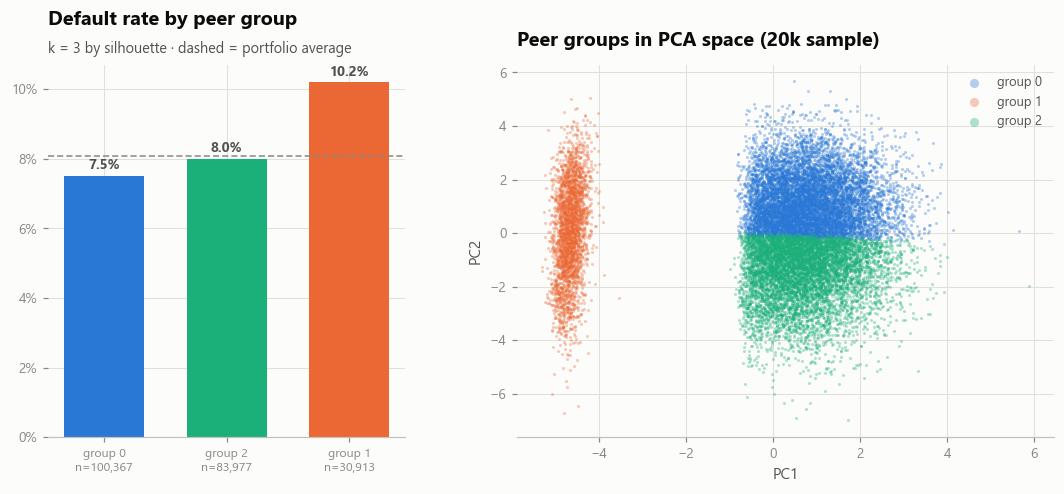

,n,default_rate,age,income,credit,ext_source,dti,buro_count
PEER_GROUP,,,,,,,,
0,100367,0.075,44.449001,157500.0,787131.0,0.544,0.210,4.0
2,83977,0.080,41.431999,135000.0,270000.0,0.502,0.114,4.0
1,30913,0.102,42.154999,135000.0,467257.5,0.518,0.178,0.0


In [6]:
# What are the peer groups, and how risky is each?
profile = train.groupby("PEER_GROUP").agg(
    n=("TARGET", "size"), default_rate=("TARGET", "mean"),
    age=("AGE_YEARS", "median"), income=("AMT_INCOME_TOTAL", "median"),
    credit=("AMT_CREDIT", "median"), ext_source=("EXT_SOURCE_MEAN", "median"),
    dti=("DTI", "median"), buro_count=("BURO_COUNT", "median"),
).round(3).sort_values("default_rate")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.8, 4.4), gridspec_kw={"width_ratios": [1, 1.5], "wspace": 0.25})

order = profile.index.tolist()
colors_by_cluster = {c: SERIES[i % len(SERIES)] for i, c in enumerate(sorted(train["PEER_GROUP"].unique()))}
ax1.bar(range(len(profile)), profile["default_rate"],
        color=[colors_by_cluster[c] for c in order], width=0.65)
ax1.axhline(y=train["TARGET"].mean(), color=MUTED, lw=1, ls=(0, (4, 2)))
ax1.set_xticks(range(len(profile)))
ax1.set_xticklabels([f"group {c}\nn={profile.loc[c, 'n']:,.0f}" for c in order], fontsize=8)
for i, v in enumerate(profile["default_rate"]):
    ax1.text(i, v + 0.002, f"{v:.1%}", ha="center", fontsize=9, fontweight="bold", color=INK_2)
ax1.set_title("Default rate by peer group")
fmt_pct(ax1)

# 2D view: PCA of the cluster space, colored by group
pca = PCA(n_components=2, random_state=config.SEED).fit(Xc_train)
pts = pca.transform(Xc_train[sample_idx])
labs = kmeans.predict(Xc_train[sample_idx])
for c in sorted(np.unique(labs)):
    m = labs == c
    ax2.scatter(pts[m, 0], pts[m, 1], s=4, alpha=0.35, color=colors_by_cluster[c],
                label=f"group {c}", linewidths=0)
ax2.legend(markerscale=3, fontsize=8.5, loc="upper right")
ax2.set_title("Peer groups in PCA space (20k sample)")
ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2")
subtitle(ax1, f"k = {best_k} by silhouette \u00b7 dashed = portfolio average")
save_figure(fig, "fe_peer_groups")
plt.show()
profile

---
## 5. Categorical Encoding Strategy (defined here, fitted in the pipelines)

| Cardinality | Columns | Encoding |
|---|---|---|
| 2–7 levels | contract type, gender, education, family status, housing… | One-hot (`handle_unknown="ignore"`) |
| 8–60 levels | `OCCUPATION_TYPE` (18), `ORGANIZATION_TYPE` (57) | One-hot too — tree models shrug, and the linear model gets a small ridge penalty |
| Missing values | all categoricals | explicit `"Missing"` level (imputer constant) |

The lists are persisted below so notebook 04 builds its `ColumnTransformer` from *this* notebook's decisions, not from re-derived guesses.

In [7]:
ID_COLS = ["SK_ID_CURR"]
TARGET_COL = "TARGET"
cat_cols = sorted(train.select_dtypes(include="object").columns)
num_cols = sorted(c for c in train.columns
                  if c not in cat_cols + ID_COLS + [TARGET_COL])
card = train[cat_cols].nunique().sort_values(ascending=False)
print(f"numeric features: {len(num_cols)}   categorical: {len(cat_cols)}")
print("\nhighest-cardinality categoricals:")
print(card.head(6).to_string())

meta = {"numeric": num_cols, "categorical": cat_cols,
        "cluster_features": CLUSTER_FEATURES, "peer_groups_k": best_k}
with open(config.PROCESSED_DIR / "feature_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

train.to_parquet(config.PROCESSED_DIR / "train_features.parquet", index=False)
val.to_parquet(config.PROCESSED_DIR / "val_features.parquet", index=False)
test.to_parquet(config.PROCESSED_DIR / "test_features.parquet", index=False)
print(f"\nsaved feature matrices: {train.shape[1]} columns each")

numeric features: 137   categorical: 16

highest-cardinality categoricals:
ORGANIZATION_TYPE             57
OCCUPATION_TYPE               18
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                7
WEEKDAY_APPR_PROCESS_START     7
WALLSMATERIAL_MODE             7



saved feature matrices: 155 columns each


---
## 6. Findings

- **The external-score combinations are the backbone** — `EXT_SOURCE_MEAN` alone scores ~0.71 AUROC; nothing else we can build from this data comes close. The model's job is to add the other features' incremental lift *on top*.
- **Bureau features carry real, independent Character signal** (overdue share, utilization ~0.55–0.60 single-feature AUROC) — worth the 1.7M-row aggregation.
- **Peer groups are balanced and interpretable** — three clusters of 100k/84k/31k applicants, with the riskiest (an isolated cluster in PCA space, dominated by thin-file borrowers) defaulting at 10.2% vs 7.5% for the safest. A modest 1.4× spread, but it comes from unsupervised structure alone and gives the business a nameable segmentation.
- Engineered capacity ratios are individually weak (as the EDA predicted for DTI) but cheap; the models decide their worth in combination.

**Next:** notebook `04_modeling.ipynb` — logistic baseline → Random Forest → gradient boosting, tuned, calibrated, and translated into a **dollar business case**.